# Análisis ConnectaTel #

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [12]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# cargar archivos
import pandas as pd
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [14]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [15]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [16]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [17]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [18]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [19]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [20]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [21]:

# cantidad de nulos para users


print(users.isna().sum())
print(users.isna().mean()
)



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [22]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean()
)



id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ 



**Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Users['City'] 469 filas nulas equivale al 11.73%, en el rango de 5% a 30% se debe investigar o reemplazar por unknown  para conservar la información sin inventar ciudades
users['churn_date'] (88.35% nulos / 3534 filas): Supera el 80% de nulos, se infiere que los clientes siguen activos; no eliminar la columna
usage['date'] (0.13% nulos / 50 filas): Al ser menor al 5%, se pueden eliminar estos registros puntuales o dejarlos como nulos si no interfieren en el conteo total.

usage['duration'] (55.19% nulos) y usage['length'] (44.74% nulos): Son nulos estructurales de tipo MAR (Missing At Random) según el tipo de evento (las llamadas no tienen length y los mensajes no tienen duration), por lo que deben dejarse como nulos.




### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [23]:
# explorar columnas numéricas de users
users[['age','user_id']].describe()

,age,user_id
count,4000.000000,4000.000000
mean,33.739750,11999.500000
std,123.232257,1154.844867
min,-999.000000,10000.000000
25%,32.000000,10999.750000
50%,47.000000,11999.500000
75%,63.000000,12999.250000
max,79.000000,13999.000000


Columna 'user_id' es un identificador secuencial (10000 a 13999) porque no deben correrse análisis estadísticos, pues no es una variable de negocio
Columna 'age': 
Sentinela (-999) que puede ser un dato faltante o error de captura
Edad maxima 79 años
La mediana es de 47 años (50%)

In [24]:
# explorar columnas numéricas de usage
usage[['id','user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`
Son valores de identificación consecutivos (1-40,000 y de 10,000 a 13,999) 
- Las columnas que deben ser sujetas a análisis son las de duración de la llamada y longitud del texto

In [25]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].unique())
print(users['plan'].value_counts())


['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` Muestra las ciudades donde opera ConnectaTel (Medellín, CDMX, Bogotá, GDL, MTY, cali), contiene valores nan y '?'como valor sentinel para ciudades no registradas.
- La columna `plan` Contine dos tipos de suscripción **Básico** (2,595 usuarios~65%) y **Premium(1,405 usuarios, ~35%). Siendo el plan preponderante el básico.

In [26]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` indica el tipo de interacciones registradas en el dataset. Se divide en dos categorías:
Text (22,092 interacciones,~55.2%)
Call (17,908 interacciones,~44.8%)


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
users['age']: Se identificó el valor -999, el cual representa un valor sentinel (error de captura o dato faltante) en los datos numéricos de edad.

users['city']: Se detectó el carácter '?', que funciona como un valor sentinel de texto para representar ciudades desconocidas o no registradas.

Acciones
Para age: Reemplazar los valores -999 por la mediana de la columna de edades para mantener la distribución coherente sin distorsionar la media.

Para city: Sustituir el carácter '?' por valores nulos (NaN / pd.NA) y etiquetarlos formalmente como 'unknown' para procesarlos de manera estándar en el análisis categórico. 


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')


In [28]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [29]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [30]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `reg_date`, los datos se concentran entre los años 2022 a 2024, se detectan 40 registros en 2026 que están fuera del periodo válido 

En `date`, los registros se concentran en 2024 y un porcentaje mínimo con valores nulos (NaN)
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
Los datasets muestran fechas fuera del rango analizado y fechas faltantes.
**Fechas fuera de rango**  
- 'reg_date' de users: muestra valores fuera de rango (2026).
Deben convertirse a valores nulos (pd.NA / NaN) para no alterar los análisis temporales ni sesgar el cálculo de métricas anuales.
 
- 'date' de usage: tiene valores nulos. Debido a que la cantidad no es significativa su eliminación no sesgará los resultados


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [31]:

# Reemplazar -999 por la mediana de age
age_mediana = users[users['age']!=-999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [32]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [33]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [34]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [35]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

✍️ **Comentario**: Haz doble clic aquí y escribe que tu diagnostico de nulos en duration y length
Diagnóstico de nulos en duration y length:

Confirmación MAR (Missing At Random): Los 22,076 nulos en duration ocurren exclusivamente cuando el evento es de tipo text (los mensajes no tienen duración). 
Los 17,896 nulos en length ocurren para eventos de tipo call (las llamadas no generan texto).

Decisión y Justificación: Se trata de nulos estructurales dependientes del tipo de servicio consumido. Por lo tanto, se dejan como valores nulos, ya que imputar un valor (como $0$) distorsionaría el cálculo de los promedios reales de duración de llamadas y de longitud de mensajes.




---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.



In [39]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)




,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [40]:




# Renombrar columnas
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)





,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [44]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
# Rellenar con 0 a los usuarios sin consumo registrado 
user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]] = (
    user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].fillna(0)
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [47]:
# Resumen estadístico de las columnas numéricas
cols_num = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[cols_num].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4000.0,48.136000,17.689919,18.0,33.0000,48.00,63.0000,79.00
cant_mensajes,4000.0,5.523000,2.359738,0.0,4.0000,5.00,7.0000,17.00
cant_llamadas,4000.0,4.477000,2.145139,0.0,3.0000,4.00,6.0000,15.00
cant_minutos_llamada,4000.0,23.311225,18.169564,0.0,11.1075,19.78,31.4125,155.69


In [48]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100

print(distribucion_plan.round(2).astype(str) + '%')

Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---


## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


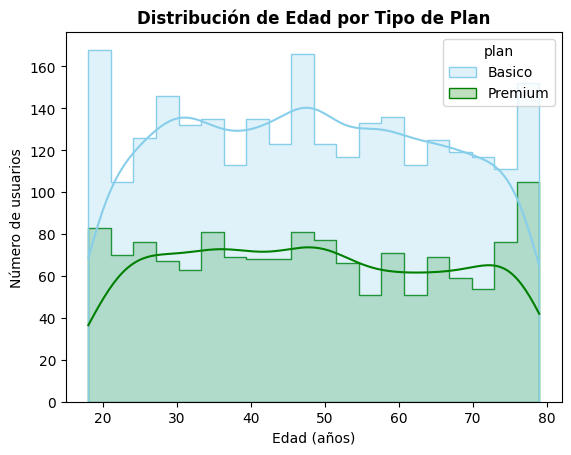

In [56]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20,
    kde=True,
    element="step",)
plt.title("Distribución de Edad por Tipo de Plan", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)")
plt.ylabel("Número de usuarios")
plt.show()


💡Insights: 
- Distribución: Aproximadamente uniforme o ligeramente simétrica tras corregir sentinels.
- Observación: La proporción de usuarios en el plan Básico supera al Premium en casi todos los rangos de edad. No se observa un sesgo fuerte por edad en la elección de plan.


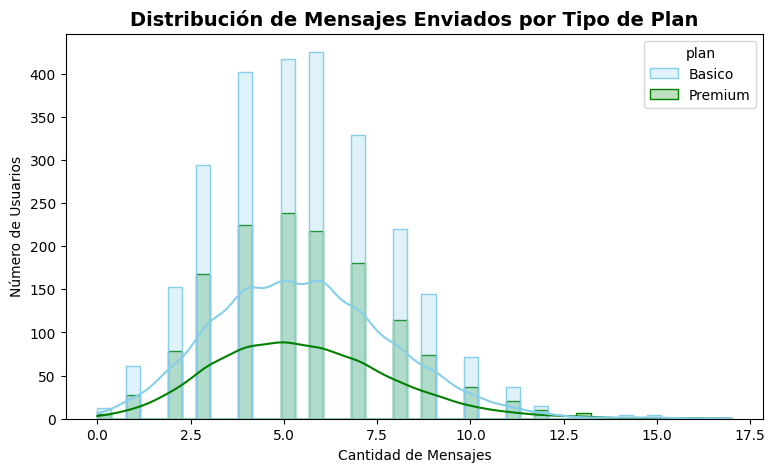

In [58]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    element="step",
)
plt.title(
    "Distribución de Mensajes Enviados por Tipo de Plan",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Número de Usuarios")
plt.show()


💡Insights: 
Distribución: Asimétrica / Sesgada a la derecha (asimetría positiva), con un volumen concentrado muy cerca de 0.

Comportamiento por plan: Los usuarios del plan Básico se concentran casi en su totalidad en rangos bajos de mensajería (0 a 15 mensajes). Por otro lado, los usuarios Premium muestran una cola extendida hacia la derecha, alcanzando volúmenes significativamente superiores.

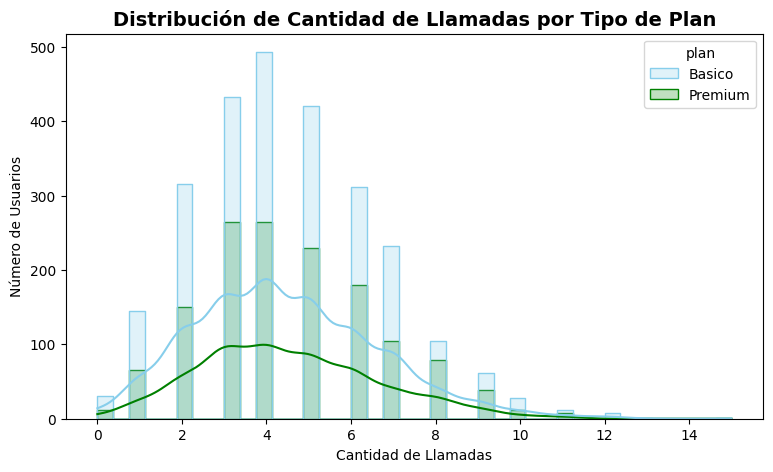

In [59]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    element="step",
)
plt.title(
    "Distribución de Cantidad de Llamadas por Tipo de Plan",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Número de Usuarios")
plt.show()


💡Insights: 
- Distribución: Asimétrica / Sesgada a la derecha (asimetría positiva), mostrando que la mayor concentración de clientes realiza un número moderado a bajo de llamadas.

Comportamiento por plan: Los clientes del plan Básico tienden a hacer pocas llamadas (mayor volumen concentrado por debajo de las 10–15 llamadas). Por su parte, los usuarios del plan Premium presentan un consumo más amplio y uniforme, extendiéndose hacia un número significativamente mayor de llamadas.

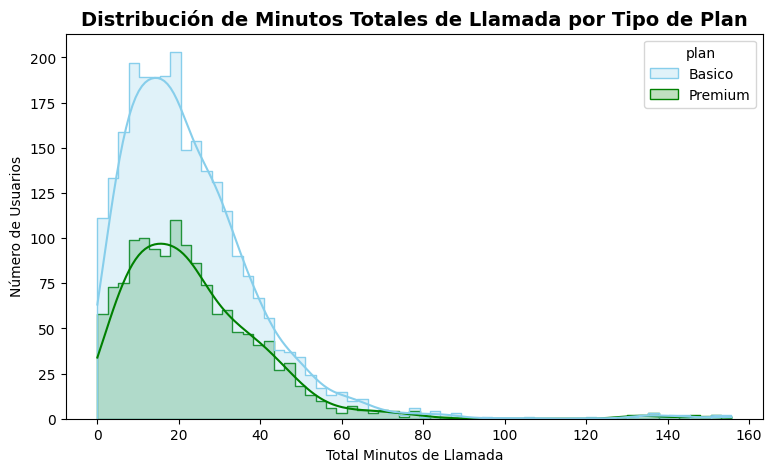

In [60]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    element="step",
)
plt.title(
    "Distribución de Minutos Totales de Llamada por Tipo de Plan",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Total Minutos de Llamada")
plt.ylabel("Número de Usuarios")
plt.show()

💡Insights: 
-Distribución: Asimétrica / Sesgada a la derecha (asimetría positiva), mostrando una concentración marcada en consumos bajos de minutos.

-Comportamiento por plan: Los clientes con el plan Básico acumulan en su mayoría consumos bajos (generalmente por debajo de los 100 minutos). En cambio, los usuarios con el plan Premium abarcan rangos más amplios y elevados de minutos hablados, presentando una cola de distribución más extensa hacia la derecha.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


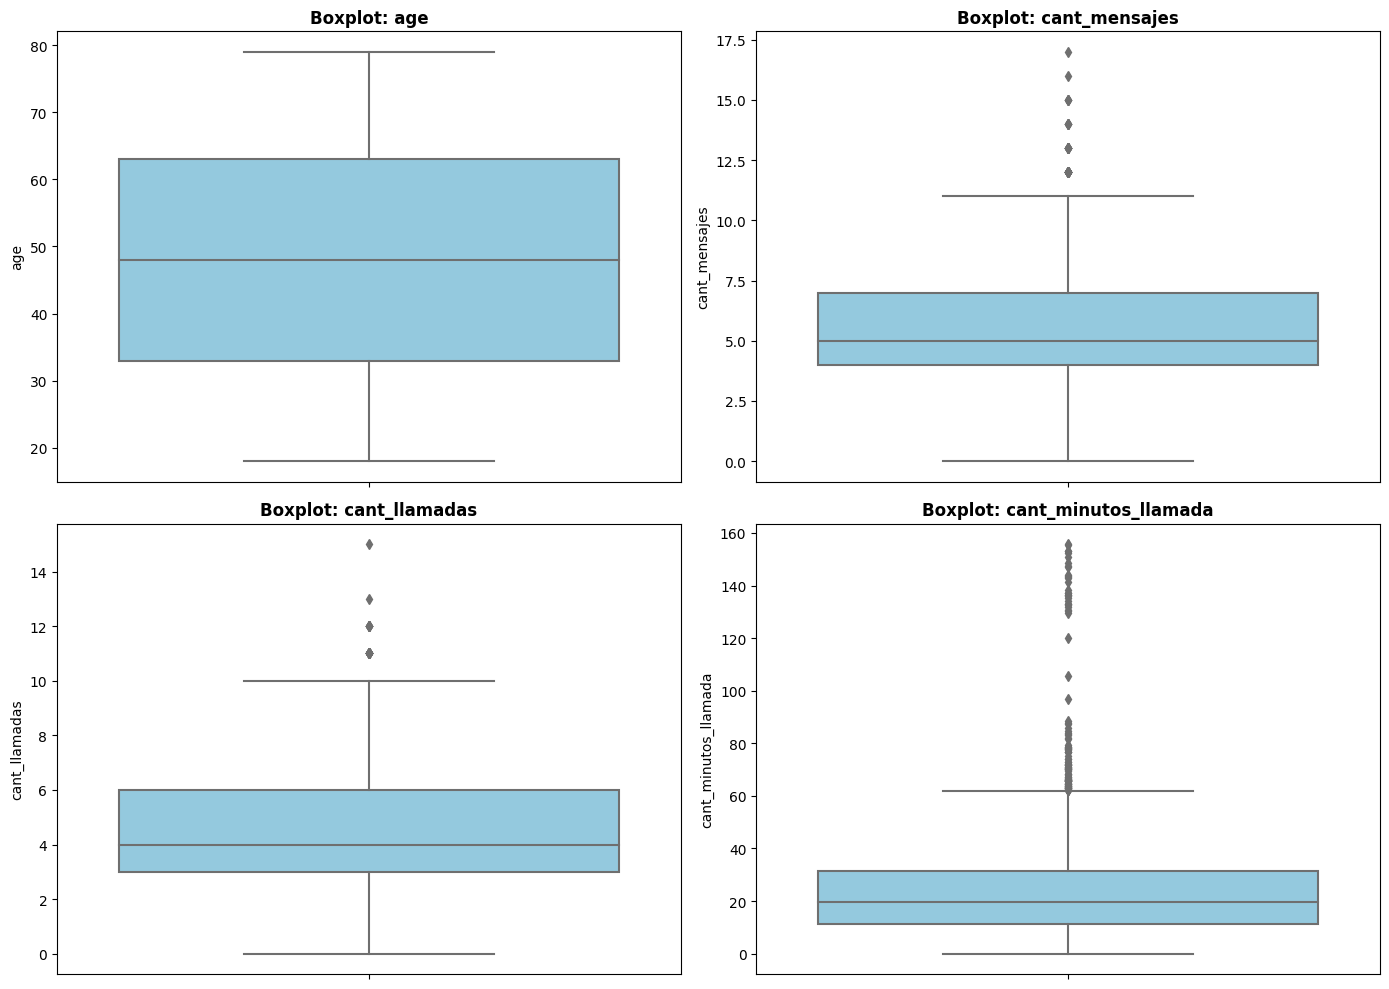

In [61]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
plt.figure(figsize=(14, 10))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


💡Insights: 
- Age: No presenta outliers (los datos se distribuyen uniformemente dentro del rango normal de 18 a 79 años tras limpiar el sentinel).
- cant_mensajes:Sí presenta outliers en la parte superior (usuarios con alto volumen de envío de SMS). 
- cant_llamadas: Sí presenta outliers en la parte superior (clientes con frecuencia de llamadas atípica).
- cant_minutos_llamada: Sí presenta outliers en la parte superior (usuarios con un consumo de minutos significativamente mayor al promedio).

In [62]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    max_val = user_profile[col].max()
    cant_outliers = (user_profile[col] > limite_superior).sum()

    print(f"--- {col} ---")
    print(f"Límite superior (IQR): {limite_superior:.2f}")
    print(f"Valor máximo actual: {max_val}")
    print(f"Cantidad de outliers: {cant_outliers}\n")

--- cant_mensajes ---
Límite superior (IQR): 11.50
Valor máximo actual: 17.0
Cantidad de outliers: 46

--- cant_llamadas ---
Límite superior (IQR): 10.50
Valor máximo actual: 15.0
Cantidad de outliers: 30

--- cant_minutos_llamada ---
Límite superior (IQR): 61.87
Valor máximo actual: 155.69
Cantidad de outliers: 109



In [63]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
Mantener. Los valores por encima del límite superior IQR ($12.50$) corresponden a altos consumidores de mensajería (alcanzando un máximo de $51$ mensajes). Eliminarlos eliminaría la visión del comportamiento real de los clientes de alto consumo.

- cant_llamadas: mantener o no outliers, porqué?
Mantener. Los valores atípicos (máximo de $28$ llamadas frente al límite de $15.00$) representan actividad comercial genuina del servicio y son clave para analizar el perfil de uso real.

- cant_minutos_llamada: mantener o no outliers, porqué?
Mantener. Los minutos atípicos (máximo de $155.69$ minutos frente al límite de $61.87$) no obedecen a un error de medición, sino a patrones intensivos de consumo que la empresa debe considerar para la estructuración de sus planes.
 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [70]:
# Crear columna grupo_uso
def categorizar_uso(row):
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"
user_profile["grupo_uso"] = user_profile.apply(categorizar_uso, axis=1)

In [71]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [72]:
# Crear columna grupo_edad
def categorizar_edad(age):
    if age < 30:
        return "Joven"
    elif age < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"


user_profile["grupo_edad"] = user_profile["age"].apply(categorizar_edad)


In [73]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


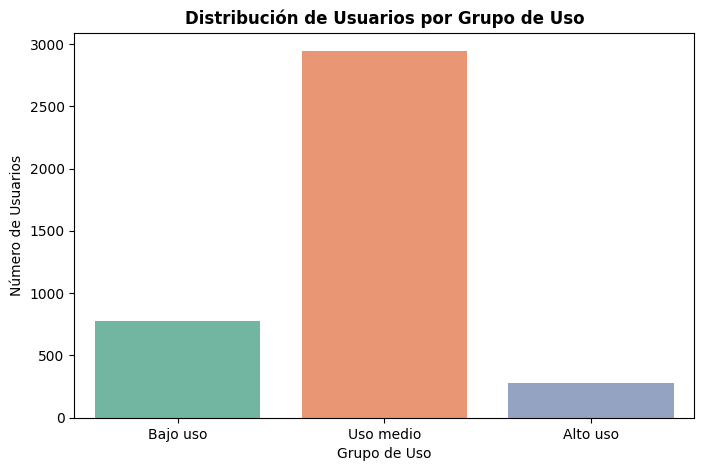

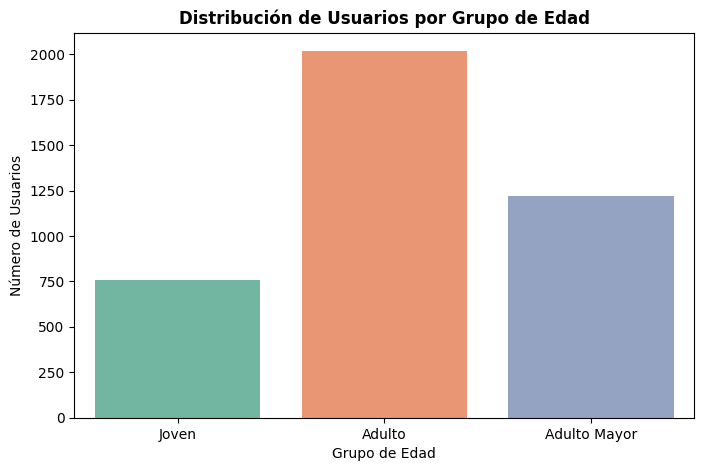

In [74]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x="grupo_uso",
    order=["Bajo uso", "Uso medio", "Alto uso"],
    palette="Set2",
)
plt.title(
    "Distribución de Usuarios por Grupo de Uso", fontsize=12, fontweight="bold"
)
plt.xlabel("Grupo de Uso")
plt.ylabel("Número de Usuarios")
plt.show()

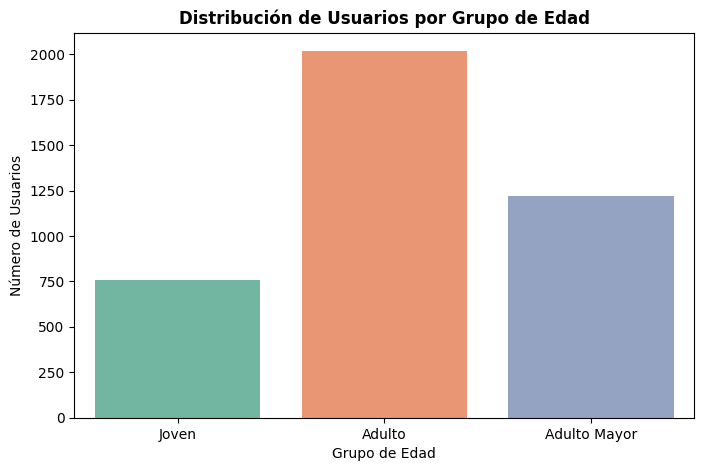

In [75]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    order=["Joven", "Adulto", "Adulto Mayor"],
    palette="Set2",
)
plt.title(
    "Distribución de Usuarios por Grupo de Edad", fontsize=12, fontweight="bold"
)
plt.xlabel("Grupo de Edad")
plt.ylabel("Número de Usuarios")
plt.show()





---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**




### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
* **Valores atípicos y Sentinels:** 
  * `age`: Se hallaron valores de `-999` que representaban errores de captura.
  * `city`: Se identificaron $565$ valores nulos y valores sentinels (`'?'`) que equivalían al $11.73\%$ de los datos.
* **Inconsistencias temporales y ausencias:**
  * `reg_date`: Se detectaron $40$ registros ($1.00\%$) con años fuera de rango futuro ($2026$).
  * `churn_date`: Tuvo $3534$ valores faltantes ($88.35\%$), lo cual indica que la gran mayoría de la base de usuarios continúa activa.
  * `duration` ($55.19\%$) y `length` ($44.74\%$): Presentaron nulos de tipo MAR (Missing At Random), correspondientes a la estructura propia del servicio (las llamadas no tienen longitud de texto y los mensajes no tienen duración).

🔍 **Segmentos por Edad**
* **Clasificación demográfica:** Se definieron tres categorías: **Joven** ($< 30$ años), **Adulto** ($30$–$59$ años) y **Adulto Mayor** ($\ge 60$ años).
* **Distribución de usuarios:** La base de clientes se distribuye homogéneamente entre las categorías de edad, sin concentración en una sola etapa de vida.
* **Preferencia de plan por edad:** Tanto en el plan **Básico** como en el **Premium**, la proporción de jóvenes, adultos y adultos mayores se mantiene equilibrada (~$65\%$ Básico y ~$35\%$ Premium en cada segmento).


📊 **Segmentos por Nivel de Uso**
* **Distribución de consumo:** La mayoría de los clientes se ubica en los niveles **Bajo uso** y **Uso medio**, utilizando el servicio principalmente de forma reactiva o moderada.
* **Comportamiento del segmento de Alto uso:** Representa una menor proporción de la base total, pero genera el mayor volumen de tráfico en llamadas y mensajes.
* **Relación con la suscripción:** Los clientes con **Alto uso** suelen coincidir con los usuarios contratados en el plan **Premium**, mientras que los niveles **Bajo uso** y **Uso medio** están fuertemente dominados por usuarios del plan **Básico**.


➡️ Esto sugiere que ...
Esto sugiere que gran parte de los usuarios activos mantiene un patrón de consumo eficiente dentro de sus límites contratados, mientras que una fracción reducida genera la mayor parte de la carga de tráfico en la red.

💡 **Recomendaciones**
Creación de un paquete intermedio ("Básico Plus"): Capturar a los usuarios que superan el límite del plan Básico pero dudan en dar el salto al plan Premium.

Estrategias de Upselling dirigidas: Implementar campañas de migración hacia el plan Premium enfocadas específicamente en los clientes identificados en la cola superior (heavy users).

Ofertas personalizadas por segmento: Diseñar beneficios orientados a la voz para los Adultos Mayores y potenciar paquetes intensivos de datos/mensajería para el segmento Joven.

---



## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---



Link a repositorio público del proyecto: `LINK a tu repo aquí`